<a href="https://colab.research.google.com/github/rmadatt/ADLAB/blob/main/Relationship_Recovery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

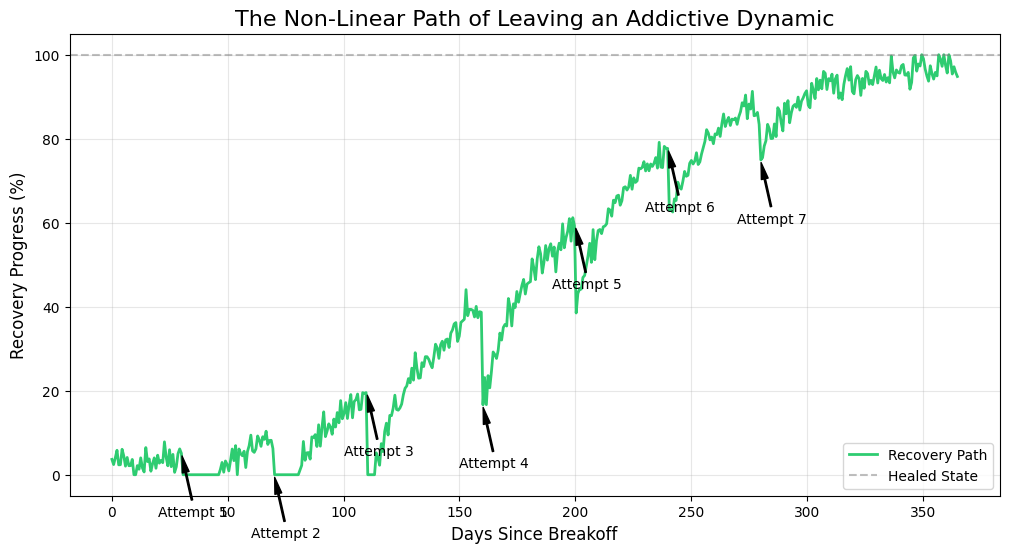

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate recovery path with backsliding stats
np.random.seed(42)
time = np.linspace(0, 365, 500)

# Base trend: Recovery of self-worth
base_trend = 100 / (1 + np.exp(-0.02 * (time - 180)))

# Simulated backsliding events (The "7 attempts" stat)
backslide_times = [30, 70, 110, 160, 200, 240, 280]
dips = np.zeros_like(time)
for t_back in backslide_times:
    mag = max(0, 40 - (t_back / 10))
    dip_effect = mag * np.exp(-0.1 * (time - t_back)) * (time >= t_back)
    dips += dip_effect

progress = base_trend - dips + np.random.normal(0, 2, len(time))
progress = np.clip(progress, 0, 100)

# Save to CSV for your records
df = pd.DataFrame({'Time_Days': time, 'Recovery_Progress': progress})
df.to_csv('recovery_data.csv', index=False)

# Create the Visual
plt.figure(figsize=(12, 6))
plt.plot(time, progress, label='Recovery Path', color='#2ecc71', linewidth=2)
plt.axhline(y=100, color='grey', linestyle='--', alpha=0.5, label='Healed State')

for i, t in enumerate(backslide_times):
    plt.annotate(f'Attempt {i+1}', xy=(t, progress[np.argmin(np.abs(time - t))]),
                 xytext=(t-10, progress[np.argmin(np.abs(time - t))] - 15),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.title('The Non-Linear Path of Leaving an Addictive Dynamic', fontsize=16)
plt.xlabel('Days Since Breakoff', fontsize=12)
plt.ylabel('Recovery Progress (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
